In [35]:
# %pip install yfinance

In [36]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

In [37]:
stock = yf.download('RELIANCE.NS', start='2022-01-01', end='2025-01-01')
stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2022-01-03,1088.746826,1090.603851,1070.494286,1071.151031,5421611
2022-01-04,1113.317505,1114.630996,1088.814624,1094.204441,10847728
2022-01-05,1118.526001,1121.877655,1101.926588,1115.083898,11643813
2022-01-06,1094.476074,1111.460525,1091.079136,1110.192319,14447422
2022-01-07,1103.308105,1113.294901,1092.234242,1101.020878,13112115


In [38]:
# save this data to csv file
stock.to_csv('reliance_stock_data.csv')

In [39]:
# shape of the data
stock.shape

(739, 5)

In [40]:
# check the missing values
stock.isnull().sum()

Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

In [41]:
# describe the data
stock.describe()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,739.000000,739.000000,739.000000,739.000000,7.390000e+02
mean,1234.296556,1245.928167,1223.372914,1234.747406,1.351479e+07
std,142.224317,143.374520,141.260106,142.325207,7.056946e+06
min,1000.238525,1008.758460,987.361121,1001.628023,2.127335e+06
25%,1126.651306,1137.654301,1116.911420,1126.008831,9.045548e+06
50%,1189.159668,1199.127352,1176.907454,1189.153532,1.199947e+07
75%,1343.088684,1356.056675,1328.985437,1341.949176,1.625930e+07
max,1581.824463,1589.630354,1566.607971,1585.332124,8.199715e+07


In [42]:
# print columns of the data
stock.columns

MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

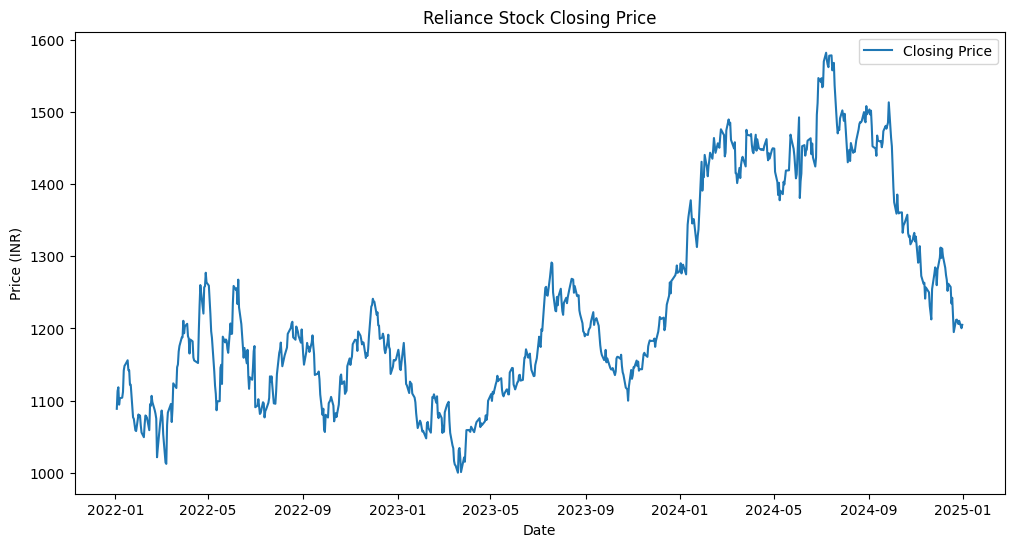

In [43]:
#  visualize the closing price of the stock
plt.figure(figsize=(12,6))
plt.plot(stock['Close'], label='Closing Price')
plt.title('Reliance Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

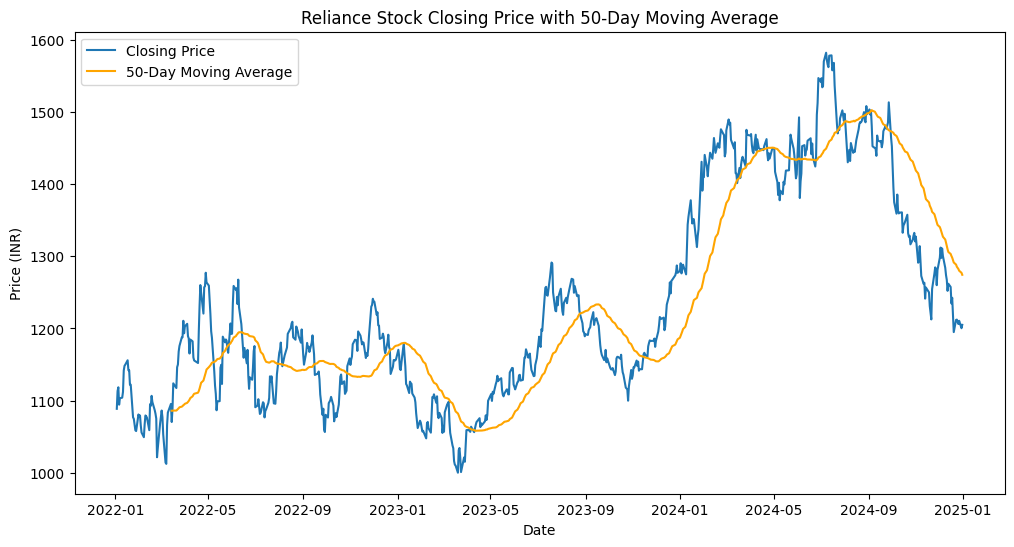

In [44]:
stock['MA50'] = stock['Close'].rolling(window=50).mean()

plt.figure(figsize=(12,6))
plt.plot(stock['Close'], label='Closing Price')
plt.plot(stock['MA50'], label='50-Day Moving Average', color='orange')
plt.title('Reliance Stock Closing Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

In [45]:
stock['MA200'] = stock['Close'].rolling(window=200).mean()

In [46]:
stock.to_csv('reliance_stock_data_with_ma.csv')

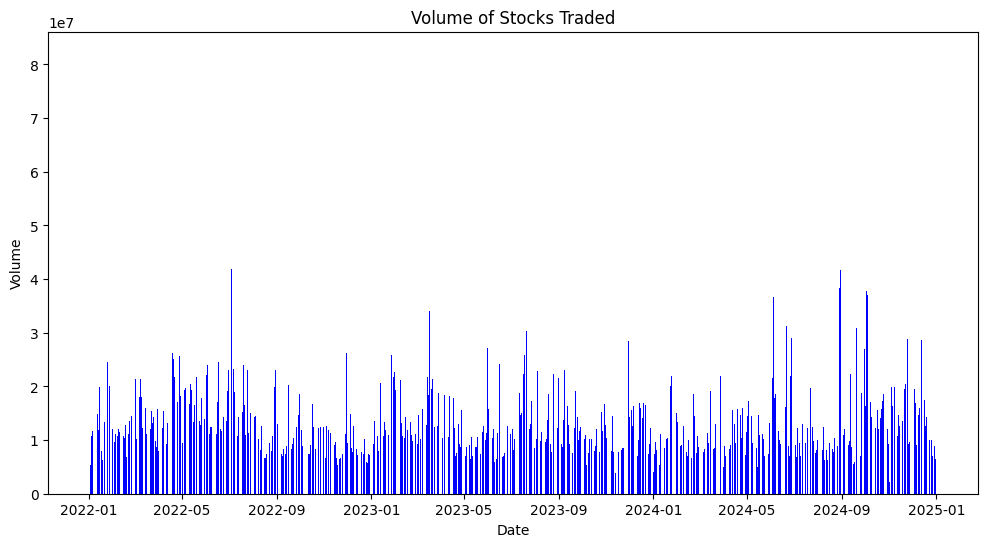

In [47]:
# bar chart for volume of stocks traded
plt.figure(figsize=(12,6))
plt.bar(stock.index, stock['Volume']['RELIANCE.NS'], color='blue')
plt.title('Volume of Stocks Traded')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

In [48]:
# candlestick chart for stock price
%pip install mplfinance


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


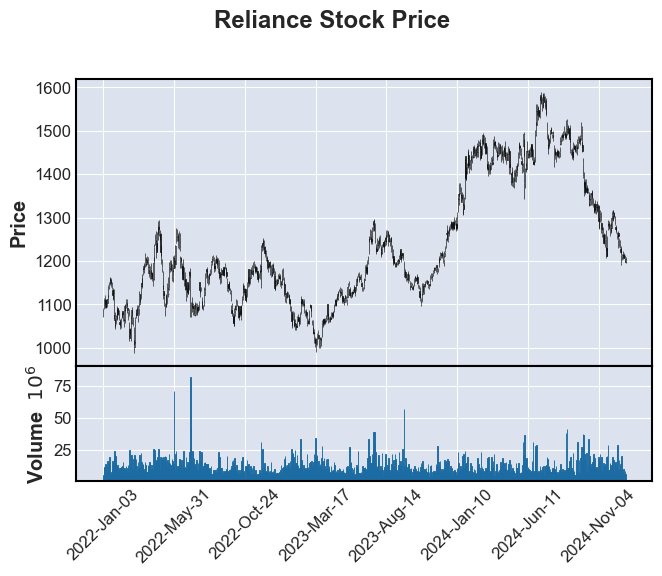

In [49]:
import mplfinance as mpf

# prepare data for candlestick chart

stock.columns = stock.columns.droplevel(1)

# step - convert into float

stock = stock.astype(float)

# plot candlestick chart
mpf.plot(stock, 
         type='candle',
         title='Reliance Stock Price', 
         volume=True)